# Boston Housing - Network Depth Comparison

# Import Libraries

In [1]:
# Import needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

2025-06-28 18:15:50.157638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751148950.182121  202974 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751148950.190055  202974 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751148950.207453  202974 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751148950.207478  202974 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751148950.207482  202974 computation_placer.cc:177] computation placer alr

# Get Boston House Price Dataset


In [2]:
# Load the data into pandas
df = pd.read_csv('housing.csv')

df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


# Split Data into X & Y

In [3]:
# Split the singular column into 14 columns (tab-delimited)
df = pd.read_csv('housing.csv', delim_whitespace=True, header=None)

df.head()

/tmp/ipykernel_202974/2686497892.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('housing.csv', delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# The features (X) is first 13 columns
X = df.iloc[:, :13]

# The output (Y) is the last column
Y = df.iloc[:, -1]

In [5]:
# Sanity check
print(X.shape)
print(Y.shape)

# Describe Features
print(X.head())
print(Y.head())

(506, 13)
(506,)
        0     1     2   3      4      5     6       7   8      9     10  \
0  0.00632  18.0  2.31   0  0.538  6.575  65.2  4.0900   1  296.0  15.3   
1  0.02731   0.0  7.07   0  0.469  6.421  78.9  4.9671   2  242.0  17.8   
2  0.02729   0.0  7.07   0  0.469  7.185  61.1  4.9671   2  242.0  17.8   
3  0.03237   0.0  2.18   0  0.458  6.998  45.8  6.0622   3  222.0  18.7   
4  0.06905   0.0  2.18   0  0.458  7.147  54.2  6.0622   3  222.0  18.7   

       11    12  
0  396.90  4.98  
1  396.90  9.14  
2  392.83  4.03  
3  394.63  2.94  
4  396.90  5.33  
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: 13, dtype: float64


# Define Initial Model

Suggested model is ≥2 fully connected hidden layers in addition to input and output layers.

Choose activation function and optimizer.

Use Mean Squared Error for loss.

In [6]:
# Model with two or more fully connected hidden layers, in addition to input and output layers
# 15, 10, 5 as hidden layer sizes
# Relu as activation function
def First_Model(args=None):

  # Initialize NN
  model = Sequential([
      # Add an Input layer to specify the input shape (To get rid of the deprecation warning)
      tf.keras.Input(shape=(13,)),
      Dense(15, activation='relu'),
      Dense(10, activation='relu'),
      Dense(5, activation='relu'),
      Dense(1)
  ])


  # Set MSE loss function and Optimizer
  model.compile(optimizer='adam', loss='mse')

  return model

In [7]:
# Run once with arbitrary epochs and batch size
# This is a sanity check, the k-fold cross validation in the next section has the data properly split + shuffle
model = First_Model()
model.fit(X, Y, epochs=100, batch_size=32, verbose=0)

# Evaluate model using Mean Squared Error
mse = model.evaluate(X, Y)
print(mse)

2025-06-28 18:15:52.366733: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.4008  
43.355342864990234


# Standardize Dataset & Pipeline

Using recommended standardizer and pipeline from scikit-learn.

In [8]:
# Create the pipeline with StandardScaler
scaler_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# k-Fold Cross Validation

In [9]:
def k_fold_cross_validation(model_func, model_params, X, Y, k=10, epoch_num=100, batch_size=32):
  # Initialize KFold
  kfold = KFold(n_splits=k, shuffle=True, random_state=1)

  # Lists to store scores for each fold
  mse_scores = []

  # Manual Cross-Validation Loop
  for fold, (train_indices, test_indices) in enumerate(kfold.split(X, Y)):
      print(f"Fold {fold+1}/{kfold.n_splits}:")
      print("-" * 40)

      # Split data
      X_train_fold, X_test_fold = X.iloc[train_indices], X.iloc[test_indices]
      Y_train_fold, Y_test_fold = Y.iloc[train_indices], Y.iloc[test_indices]

      # Apply scaling using the pipeline
      X_train_scaled = scaler_pipeline.fit_transform(X_train_fold)
      X_test_scaled = scaler_pipeline.transform(X_test_fold)

      # Create and train the Keras model manually for this fold
      model = model_func(model_params) # Create a new instance of the model for each fold
      model.fit(X_train_scaled, Y_train_fold, epochs=epoch_num, batch_size=batch_size, verbose=0)

      # Make predictions on the scaled test data for this fold
      predictions_fold = model.predict(X_test_scaled)

      # Calculate and store scores for this fold
      mse = mean_squared_error(Y_test_fold, predictions_fold)

      mse_scores.append(mse)

      print(f"Fold {fold+1} MSE: {mse:.4f}")
      print("\n")

  # Print the average scores across all folds
  print("\n--- Average Scores ---")
  print(f"Average MSE: {np.mean(mse_scores):.4f}")

  # Print the standard deviation of the scores
  print("\n--- Score Standard Deviation ---")
  print(f"MSE Std Dev: {np.std(mse_scores):.4f}")

  return mse_scores

In [10]:
k_fold_cross_validation(First_Model, None, X, Y)

Fold 1/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Fold 1 MSE: 9.9303


Fold 2/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Fold 2 MSE: 10.4265


Fold 3/10:
----------------------------------------
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fcad0178e50> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/pyth

[9.930344218624306,
 10.42654921994275,
 7.972177415710423,
 35.40872244407702,
 11.18844913538307,
 14.08602758130501,
 11.194430283551718,
 17.599069053954594,
 23.52758916042061,
 9.249934622902556]

## Test for Epochs, Batch size, and k-Folds

Keep the means of the returned results and then plot to see what would be good parameters moving forward.

In [11]:
# Quick and dirty guesses, don't want it to take too long to run, just need a general idea of trends of performance
k = [5, 10, 15]
batch_size = [32, 64, 128]
epochs = [50, 100, 150]

# Keep the means of the returned lists
results = []

for k_size in k:
  print(f"K: {k_size}")
  for batch in batch_size:
    print(f"Batch Size: {batch}")
    for epoch in epochs:
      print(f"Epochs: {epoch}")
      tmp = k_fold_cross_validation(First_Model, None, X, Y, k=k_size, epoch_num=epoch, batch_size=batch)
      print("\n")

      # Use this format to change into Dataframe later
      results.append((k_size, batch, epoch, np.mean(tmp)))

df = pd.DataFrame(results, columns=['k', 'batch_size', 'epochs', 'mean_mse'])

K: 5
Batch Size: 32
Epochs: 50
Fold 1/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Fold 1 MSE: 17.8517


Fold 2/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Fold 2 MSE: 22.8129


Fold 3/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 3 MSE: 505.9135


Fold 4/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Fold 4 MSE: 24.0787


Fold 5/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 5 MSE: 19.2880



--- Average Scores ---
Average MSE: 117.9890

--- Score Standard Deviation ---
MSE Std Dev: 193.9755


Epochs: 100
Fold 1/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Fold 1 MSE: 12.0152


Fold 2/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 2 MSE: 18.8251


Fold 3/5:
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━

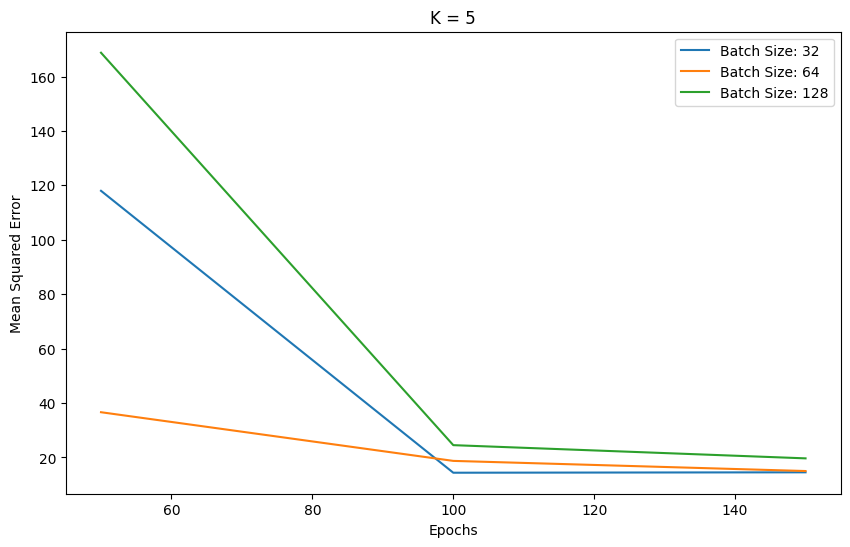

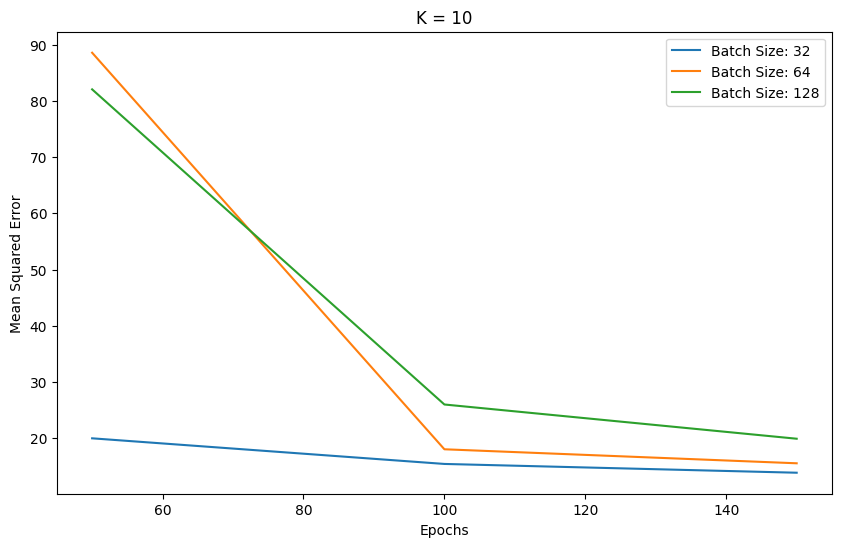

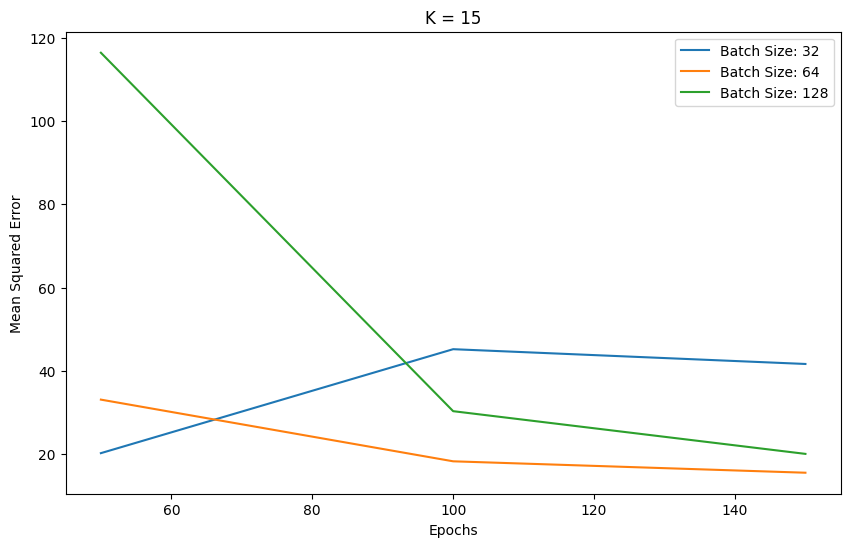

In [12]:
# Plots 3 graphs for each k, multiple lines per graph using batch size and epoch num
for k_size in k:
  tmp = df[df['k'] == k_size]
  plt.figure(figsize=(10, 6))
  for batch in batch_size:
    tmp2 = tmp[tmp['batch_size'] == batch]
    plt.plot(tmp2['epochs'], tmp2['mean_mse'], label=f'Batch Size: {batch}')
    plt.xlabel('Epochs')
  plt.ylabel('Mean Squared Error')
  plt.title(f'K = {k_size}')
  plt.legend()
  plt.show()
  print("\n")

In [13]:
# Print row with lowest MSE in df
print(df.loc[df['mean_mse'].idxmin()])

k              10.000000
batch_size     32.000000
epochs        150.000000
mean_mse       13.880088
Name: 11, dtype: float64


Judging from the graphs, good parameters to use would be k = 10, batch size = 32, and epochs = 100 or 150.

# Define One Hidden Layer Model

In [14]:
def One_Layer_Model(layer_size):

  # Initialize NN
  model = Sequential([
      # Add an Input layer to specify the input shape (To get rid of the deprecation warning)
      tf.keras.Input(shape=(13,)),
      Dense(layer_size, activation='relu'),
      Dense(1)
  ])

  model.compile(optimizer='adam', loss='mse')

  return model

Size: 52
Fold 1/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Fold 1 MSE: 13.4321


Fold 2/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Fold 2 MSE: 21.5305


Fold 3/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Fold 3 MSE: 8.0983


Fold 4/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Fold 4 MSE: 30.2434


Fold 5/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Fold 5 MSE: 12.1488


Fold 6/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Fold 6 MSE: 14.1139


Fold 7/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Fold 7 MSE: 11.9516


Fold 8/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Fold 8 MSE: 24.5718


Fold 9/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Fold 9

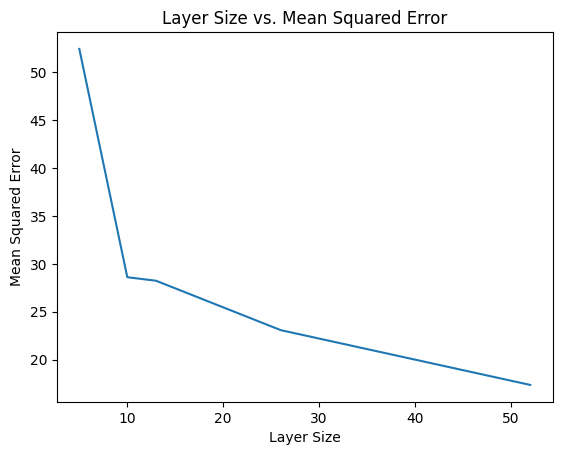

In [15]:
# Figure out what is a good size
one_layer_sizes = [52, 26, 13, 10, 5]

# Average MSE mean
results = []

for size in one_layer_sizes:
  print(f"Size: {size}")
  tmp = k_fold_cross_validation(One_Layer_Model, size, X, Y)
  results.append(np.mean(tmp))

# Plot layer size against mean MSE
plt.plot(one_layer_sizes, results)
plt.xlabel('Layer Size')
plt.ylabel('Mean Squared Error')
plt.title('Layer Size vs. Mean Squared Error')
plt.show()

How difficult was it to find an appropriate set of hidden units to solve this problem?

It took a while of processing, but there seems to be an dimishing returns between 10 and 30 fully connected nodes in the hidden layer. To reach the threshold of ≤ 20 MSE (in thousands) using just one hidden layer seems to require around 50 or more nodes.

# Define Generalized Model

In [16]:
def Generalized_Model(layers):

  # Initialize NN
  model = Sequential([
      # Add an Input layer to specify the input shape (To get rid of the deprecation warning)
      tf.keras.Input(shape=(13,)),
  ])
  for layer_size in layers:
    model.add(Dense(layer_size, activation='relu'))
  model.add(Dense(1))

  model.compile(optimizer='adam', loss='mse')

  return model

In [17]:
k_fold_cross_validation(Generalized_Model, [32, 16, 8], X, Y)

Fold 1/10:
----------------------------------------


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Fold 1 MSE: 8.6759


Fold 2/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Fold 2 MSE: 8.8265


Fold 3/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Fold 3 MSE: 5.8222


Fold 4/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Fold 4 MSE: 37.7571


Fold 5/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Fold 5 MSE: 5.3067


Fold 6/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Fold 6 MSE: 14.4011


Fold 7/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Fold 7 MSE: 8.6450


Fold 8/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Fold 8 MSE: 14.5031


Fold 9/10:
----------------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Fold 9 MSE: 17.0670


Fold 10/10:
-------------------------------------

[8.675887767162598,
 8.826502409866515,
 5.822195116049623,
 37.757081524857504,
 5.306690179677101,
 14.401077278453794,
 8.644969419089438,
 14.503149442274758,
 17.06701009405294,
 8.630282439934792]

# Experiments

Do some experiments to determine whether the depth of a network has any significant effect on how quickly your network can converge to a good solution.

Convergence condition set as < 20 MSE.

Record time and number of epochs to reach convergence.

In [18]:
def convergence_experiment(model_func, model_params, X, Y, k=10, batch_size=32, max_epochs=200):
  # Initialize KFold
  kfold = KFold(n_splits=k, shuffle=True, random_state=1)

  # Lists to store results for each fold
  fold_results = []

  # Cross-Validation Loop
  for fold, (train_indices, test_indices) in enumerate(kfold.split(X, Y)):
      print(f"Fold {fold+1}/{kfold.n_splits}:")
      print("-" * 40)

      # Split data
      X_train_fold, X_test_fold = X.iloc[train_indices], X.iloc[test_indices]
      Y_train_fold, Y_test_fold = Y.iloc[train_indices], Y.iloc[test_indices]

      # Apply scaling using the pipeline
      X_train_scaled = scaler_pipeline.fit_transform(X_train_fold)
      X_test_scaled = scaler_pipeline.transform(X_test_fold)

      # Create a new instance of the Keras model for this fold
      # If model_params are provided, pass them to the model_func
      model = model_func(model_params)

      # Init the time and epoch counters
      epochs_taken = 0
      total_training_time = 0
      converged = False
      current_mse = 30000 # Some randomly large num

      # Training loop with convergence check and precise timing
      for epoch in range(1, max_epochs + 1):
          # Start timing for this epoch
          start_time = time.time()

          # Train the model for one epoch
          model.fit(X_train_scaled, Y_train_fold, epochs=1, batch_size=batch_size, verbose=0)
          epochs_taken = epoch

          # Stop timing epoch
          end_time = time.time()
          total_training_time += (end_time - start_time)

          # Evaluate after each epoch (timing is paused during this)
          predictions_fold = model.predict(X_test_scaled, verbose=0)
          current_mse = mean_squared_error(Y_test_fold, predictions_fold)

          print(f"  Epoch {epoch}: MSE = {current_mse:.4f}", end='\r')

          # Check for our convergence condition
          if current_mse < 20:
              converged = True
              break # Stop training for this fold if converged

      # If the loop finished without converging, print a message
      if not converged:
          print(f"\nFold {fold+1} did not converge within {max_epochs} epochs.")

      print(f"\nFold {fold+1} Finished:")
      print(f"  Converged: {converged}")
      print(f"  Epochs taken: {epochs_taken}")
      print(f"  Total training time: {total_training_time:.2f} seconds")
      print(f"  Final MSE: {current_mse:.4f}")
      print("-" * 40)


      fold_results.append({
          'fold': fold + 1,
          'converged': converged,
          'epochs_taken': epochs_taken,
          'total_training_time': total_training_time,
          'final_mse': current_mse,
      })

  # Convert results to a DataFrame
  results_df = pd.DataFrame(fold_results)

  # Print summary statistics
  print("\n--- Summary Statistics Across Folds ---")
  print(results_df.describe())

  return results_df

## Runs

I didn't know which one to try so I decided to try two approaches. Decreasing layer size, or fixed layer size.

In [19]:
# Setup different network sizes to see results
fixed_network_sizes = [
    [26],
    [26, 26],
    [26, 26, 26]
  ]

mean_epochs_fixed = []
mean_times_fixed = []

for size in fixed_network_sizes:
  print(f"Size: {size}")
  results_df = convergence_experiment(Generalized_Model, size, X, Y)
  mean_epochs_fixed.append(results_df['epochs_taken'].mean())
  mean_times_fixed.append(results_df['total_training_time'].mean())

Size: [26]
Fold 1/10:
----------------------------------------
  Epoch 96: MSE = 19.96526
Fold 1 Finished:
  Converged: True
  Epochs taken: 96
  Total training time: 8.86 seconds
  Final MSE: 19.9652
----------------------------------------
Fold 2/10:
----------------------------------------
  Epoch 127: MSE = 19.8489
Fold 2 Finished:
  Converged: True
  Epochs taken: 127
  Total training time: 12.62 seconds
  Final MSE: 19.8489
----------------------------------------
Fold 3/10:
----------------------------------------
  Epoch 43: MSE = 19.34988
Fold 3 Finished:
  Converged: True
  Epochs taken: 43
  Total training time: 4.26 seconds
  Final MSE: 19.3498
----------------------------------------
Fold 4/10:
----------------------------------------
  Epoch 200: MSE = 35.6452
Fold 4 did not converge within 200 epochs.

Fold 4 Finished:
  Converged: False
  Epochs taken: 200
  Total training time: 18.02 seconds
  Final MSE: 35.6452
----------------------------------------
Fold 5/10:
-----

In [20]:
network_sizes = [
    [26],
    [26, 13],
    [26, 13, 6]
    ]

mean_epochs = []
mean_times = []

for size in network_sizes:
  print(f"Size: {size}")
  results_df = convergence_experiment(Generalized_Model, size, X, Y)
  mean_epochs.append(results_df['epochs_taken'].mean())
  mean_times.append(results_df['total_training_time'].mean())

Size: [26]
Fold 1/10:
----------------------------------------
  Epoch 107: MSE = 19.9941
Fold 1 Finished:
  Converged: True
  Epochs taken: 107
  Total training time: 10.76 seconds
  Final MSE: 19.9941
----------------------------------------
Fold 2/10:
----------------------------------------
  Epoch 137: MSE = 19.8858
Fold 2 Finished:
  Converged: True
  Epochs taken: 137
  Total training time: 14.10 seconds
  Final MSE: 19.8858
----------------------------------------
Fold 3/10:
----------------------------------------
  Epoch 57: MSE = 19.67570
Fold 3 Finished:
  Converged: True
  Epochs taken: 57
  Total training time: 6.11 seconds
  Final MSE: 19.6757
----------------------------------------
Fold 4/10:
----------------------------------------
  Epoch 200: MSE = 31.0441
Fold 4 did not converge within 200 epochs.

Fold 4 Finished:
  Converged: False
  Epochs taken: 200
  Total training time: 20.71 seconds
  Final MSE: 31.0441
----------------------------------------
Fold 5/10:
---

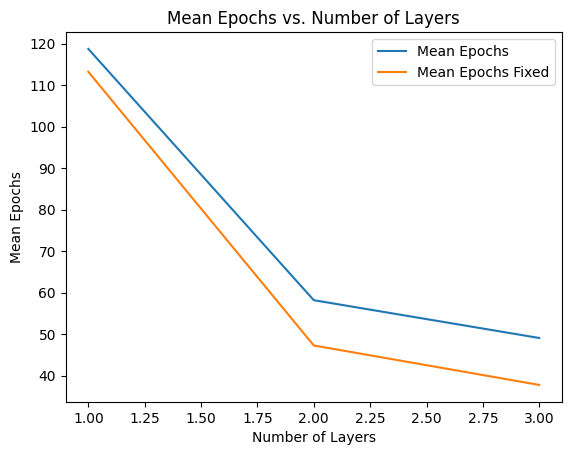

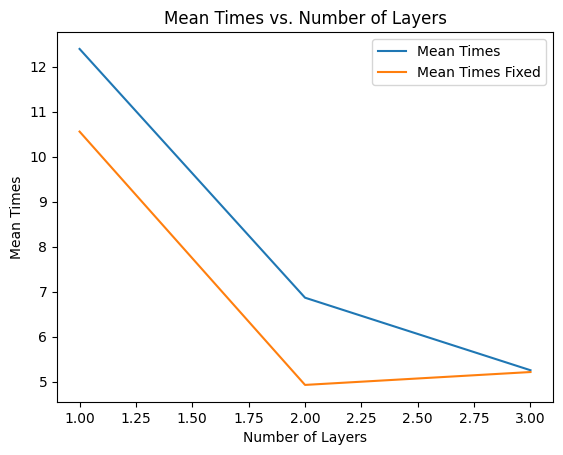

In [21]:
num_layers = [1, 2, 3]

# Plot the two mean epochs as lines on a plot
plt.plot(num_layers, mean_epochs, label='Mean Epochs')
plt.plot(num_layers, mean_epochs_fixed, label='Mean Epochs Fixed')
plt.xlabel('Number of Layers')
plt.ylabel('Mean Epochs')
plt.title('Mean Epochs vs. Number of Layers')
plt.legend()
plt.show()

# Plot the two mean times as lines on a plot
plt.plot(num_layers, mean_times, label='Mean Times')
plt.plot(num_layers, mean_times_fixed, label='Mean Times Fixed')
plt.xlabel('Number of Layers')
plt.ylabel('Mean Times')
plt.title('Mean Times vs. Number of Layers')
plt.legend()
plt.show()